<div align="center">

# <span style="color: #3498db;">CA2 - Genetic and Games Algorithm</span>

**<span style="color:rgb(247, 169, 0);">[Faezeh Khanmohammadi]</span> - <span style="color:rgb(143, 95, 195);">[810003042]</span>**

</div>

# <span style="color: #3498db;">Genetic Algorithm</span>

## Imports

In [1]:
from bisect import bisect_left
from dataclasses import dataclass
from itertools import accumulate
from random import randrange, random, uniform
from typing import List, Tuple, Callable

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

In [ ]:
class ImageAnalysis:
    def __init__(self, image: Image, rows: int, columns: int):
        self._image = image
        self._rows = rows
        self._columns = columns
        self._pieces = self._split_image()
        self._dissimilarity_matrix = self._calculate_dissimilarity_matrix()

    @property
    def pieces(self) -> dict:
        return self._pieces

    def get_dissimilarity(self, ids: tuple, orientation: str) -> float:
        return self._dissimilarity_matrix[ids][orientation]

    def _split_image(self) -> dict:
        width, height = self._image.size
        piece_width = width // self._columns
        piece_height = height // self._rows

        pieces = {}
        for i in range(self._rows):
            for j in range(self._columns):
                left = j * piece_width
                top = i * piece_height
                right = left + piece_width
                bottom = top + piece_height
                piece = self._image.crop((left, top, right, bottom))
                pieces[i * self._columns + j] = piece
        return pieces

    def _calculate_dissimilarity_matrix(self) -> dict:
        matrix = {}
        for i in range(self._rows * self._columns):
            for j in range(self._rows * self._columns):
                if i == j:
                    continue
                matrix[i, j] = {
                    "L-R": self._dissimilarity_measure(self._pieces[i], self._pieces[j], "L-R"),
                    "T-D": self._dissimilarity_measure(self._pieces[i], self._pieces[j], "T-D"),
                }
        return matrix

    def _dissimilarity_measure(self, piece1: Image, piece2: Image, orientation: str) -> float:
        
         
        image_array1 = np.asarray(piece1)
        image_array2 = np.asarray(piece2)

    
        if orientation == "L-R":
            edge1 = image_array1[:, -1, ...]
            edge2 = image_array2[:, 0,  ...]
        elif orientation == "T-D":
            edge1 = image_array1[-1, :, ...] 
            edge2 = image_array2[0,  :, ...] 

        edge1 = edge1.astype(np.float32)
        edge2 = edge2.astype(np.float32)

        difference = edge1 - edge2
        ssd = float(np.sum(difference ** 2))

        return ssd
        



## Image Analysis

### ImageAnalysis Class

The `ImageAnalysis` class is responsible for two main tasks:

1.  **Splitting the Image**: It takes the source image and splits it into a grid of smaller puzzle pieces.
2.  **Calculating Dissimilarity**: It computes a "dissimilarity matrix," which stores a score of how well any two pieces fit together. This is crucial for the genetic algorithm's fitness function.

You will need to implement the `_dissimilarity_measure` method, which is the core of the analysis. The rest of the class is provided for you.

### Task: Implement the `dissimilarity_measure` Method

The `dissimilarity_measure` method calculates how different two puzzle pieces are when placed next to each other. This is a key part of the fitness function, as it determines how well pieces fit together.

#### What You Need to Do:

-   **Implement the `_dissimilarity_measure` method** in the `ImageAnalysis` class.
-   The method should take two `PIL.Image` objects (`piece1`, `piece2`) and an `orientation` string (`"L-R"` for left-right or `"T-D"` for top-down).
-   It should return a single `float` value representing the dissimilarity.

#### Hints:

1.  **Convert Images to NumPy Arrays**: Use `np.asarray(piece)` to convert the `PIL.Image` objects into NumPy arrays. This makes it easier to perform mathematical operations on the pixel data.

2.  **Extract Edges**: Depending on the `orientation`, you need to extract the pixels from the touching edges of the two pieces.
    -   For `"L-R"` (Left-Right), you need the **right edge of `piece1`** and the **left edge of `piece2`**.
    -   For `"T-D"` (Top-Down), you need the **bottom edge of `piece1`** and the **top edge of `piece2`**.

3.  **Calculate Dissimilarity**: The dissimilarity can be calculated as the **sum of squared differences** between the pixel values of the two edges. The formula is:

    ```
    dissimilarity = sum((edge1 - edge2)^2)
    ```

    You can use `np.sum()` and basic arithmetic operations on the NumPy arrays to compute this value.

## Size Detector

In [3]:
class SizeDetector:
    def __init__(self, image: Image):
        self._image = image

    def detect(self) -> tuple:
        width, height = self._image.size
        aspect_ratio = width / height

        for i in range(1, int(width**0.5) + 1):
            if width % i == 0:
                j = width // i
                if abs(j / i - aspect_ratio) < 0.1:  # Heuristic for aspect ratio
                    return (i, j) if width > height else (j, i)
        return (1, width) # Fallback

## Size Detector

### SizeDetector Class

The `SizeDetector` class automatically determines the size of the puzzle pieces from the input image. It works by analyzing the image's properties and looking for repeating patterns that suggest the dimensions of the pieces.

This class is provided to you and does not require any modifications. You can use it to get the piece size before starting the genetic algorithm.

## Individual

### Task: Implement the `Individual` Class

The `Individual` class represents a possible solution to the jigsaw puzzle. It stores the puzzle pieces and evaluates how well they fit together. You will need to implement several parts of this class to calculate the fitness and manage the puzzle pieces.

#### 1. Fitness Calculation (`fitness` property)

- **What You Need to Do**:
  - Implement the `fitness` property to calculate how well the pieces fit together.
  - The fitness value should be based on how the pieces align (i.e., their edges) both horizontally and vertically.
  - The fitness function should return an inverse fitness value based on the dissimilarities between adjacent pieces.

  **Hint**:
  - Use the `ImageAnalysis.get_dissimilarity(ids, orientation)` function to get the dissimilarity between adjacent pieces.
  - Calculate the dissimilarity between adjacent pieces both **horizontally** and **vertically** (Left-Right and Top-Down).

#### 2. Core Methods (`__init__`, `piece_size`, `piece_by_id`)

- **What You Need to Do**:
  - Implement the `__init__` method to initialize the puzzle with pieces and store the number of rows and columns.
  - Implement the `piece_size()` method to return the size of a single piece.
  - Implement the `piece_by_id()` method to retrieve a piece by its unique ID.

---

#### Parts You **Do Not Need to Implement**:

- **`edge` Method**:
  - This method checks the neighboring piece's ID based on orientation (top, right, bottom, left). It is useful for advanced puzzle assembly but is **not necessary** for this task. You can **skip** implementing this method.

- **`to_image` Method**:
  - This method reassembles the individual puzzle into a complete image. It is used for **visualization** of the solution and is **not required** for fitness evaluation. You can **skip** implementing this method.

In [ ]:
class Individual:
    def __init__(self, pieces: dict, rows: int, columns: int, initial_state: List[int] = None, analysis=None):
       
        

        self.pieces = pieces
        self._rows = rows
        self._columns = columns
        self.analysis = analysis
        
        num_pieces = rows * columns
        
        if initial_state is None:
            self._chromosome = np.array(sorted(pieces.keys()))
        else:
            if len(initial_state) != num_pieces:
                 raise ValueError(f"Length must be {num_pieces}")
            self._chromosome = np.array(initial_state) 
          

    @property
    def fitness(self):
        """Calculate the fitness of the individual."""
         
        grid = self._chromosome.reshape(self._rows, self._columns)
        
        total_dissimilarity = 0.0
        
        for i in range(self._rows):
            for j in range(self._columns):
                current_id = grid[i, j]
                
                # check right hamsaye
                if j < self._columns - 1:
                    right_id = grid[i, j + 1]
                    total_dissimilarity += self.analysis.get_dissimilarity((current_id, right_id), "L-R")
                
                # check down hamsaye
                if i < self._rows - 1:
                    bottom_id = grid[i + 1, j]
                    total_dissimilarity += self.analysis.get_dissimilarity((current_id, bottom_id), "T-D")

        epsilon = 1e-10
        return 1.0 / (total_dissimilarity + epsilon)
         

    def piece_size(self) -> tuple:
        """Return the size of a single piece."""
         
        first_piece = next(iter(self.pieces.values()))
        return first_piece.size
         

    def piece_by_id(self, piece_id: int) -> Image:
        """Return the piece image by its ID."""
         
        return self.pieces[piece_id]
         

    def to_image(self) -> Image:
        """Reassembles the individual into a single image."""
        piece_width, piece_height = self.piece_size()
        canvas_width = self._columns * piece_width
        canvas_height = self._rows * piece_height
        canvas = Image.new('RGB', (canvas_width, canvas_height))

        
        # i changed it to reshape the 1D chromosome into a 2D grid for visualization
        grid = self._chromosome.reshape(self._rows, self._columns)
        

        for i in range(self._rows):
            for j in range(self._columns):
                
                # i changed it to  Use the temp 'grid' variable  not self._chromosome
                piece_id = grid[i, j] 
                piece = self.piece_by_id(piece_id)
                canvas.paste(piece, (j * piece_width, i * piece_height))
        return canvas
    
    def __getitem__(self, key):
        return self._chromosome[key]

    def __repr__(self):
        return f"Individual(fitness={self.fitness})"


## Selection

### Task: Implement the `roulette_selection` Function

The **roulette selection** process is part of the genetic algorithm and is used to select pairs of individuals from the population based on their **fitness**. The fitter individuals are more likely to be selected for reproduction, but all individuals still have a chance of being selected, even if their fitness is low.

---

#### **Hints**:

- You can use `random.uniform(0, total_sum)` to generate a random number between 0 and the total fitness sum.
- The `bisect_left` function helps find the position in the probability intervals where the random number fits.
- The **elites** are guaranteed to move to the next generation without crossover, so they should be excluded from the random selection process.

---

### Task: Implement Another Selection Method

Besides `roulette_selection`, there are other selection strategies. Implement one of the following:

1.  **Tournament Selection**:
    -   Randomly select a few individuals (a "tournament").
    -   The individual with the best fitness in the tournament is chosen as a parent.
    -   Repeat to select the second parent.

2.  **Rank Selection**:
    -   Rank the individuals by fitness.
    -   Selection probability is based on rank, not fitness value. This can prevent premature convergence.

In [ ]:

# added some imports i needed but were not in import part
import random
from bisect import bisect_left
from typing import List, Tuple

def roulette_selection(population: List[Individual], elite_size: int) -> List[Tuple[Individual, Individual]]:
    if len(population) <= elite_size:
        # Not enough individuals to do anything 
        return []

    # First we rank everyone based on fitness, descending
    sorted_pop = sorted(population, key=lambda x: x.fitness, reverse=True)

    # We're ignoring elites — assuming they survive automatically
    remaining = sorted_pop[elite_size:]

    # Create a simple list of fitness values
    fit_vals = []
    for indiv in remaining:
        fit_vals.append(indiv.fitness)

    total_fit = sum(fit_vals)

    # fallback — if all fitnesses are 0, we'll just assign flat probabilities
    if total_fit == 0:
        fit_vals = [1.0 for _ in remaining]
        total_fit = float(len(fit_vals))

    # Build up a cumulative list for roulette wheel
    cumulative_probs = []
    tally = 0.0
    for val in fit_vals:
        tally += val
        cumulative_probs.append(tally)

    # Helper function to simulate a spin of the wheel
    def spin_the_wheel():
        spin_val = random.uniform(0, total_fit)
        chosen_idx = bisect_left(cumulative_probs, spin_val)
        if chosen_idx >= len(remaining):
            # shouldn't happen, but just in case
            chosen_idx = len(remaining) - 1
        return remaining[chosen_idx]

    # We'll pair up individuals, skiping elites
    pairs_to_form = (len(population) - elite_size) // 2
    parent_pairs = []

    for _ in range(pairs_to_form):
        # Note: might end up with same individual twice
        first = spin_the_wheel()
        second = spin_the_wheel()
        parent_pairs.append((first, second))

    return parent_pairs


# Another approach : tournament selection c
def your_other_selection_method(population: List[Individual], elite_size: int) -> List[Tuple[Individual, Individual]]:
    if len(population) <= elite_size:
        # nothing to select here
        return []

    ordered = sorted(population, key=lambda guy: guy.fitness, reverse=True)
    contenders = ordered[elite_size:]

    num_needed = (len(population) - elite_size) // 2
    picks = []
    t_size = 3  # default tournament size; maybe make this configurable later?

    for i in range(num_needed):
        #  pick first parent
        try:
            group1 = random.sample(contenders, t_size)
            p1 = max(group1, key=lambda dude: dude.fitness)

            # and now the second one
            group2 = random.sample(contenders, t_size)
            p2 = max(group2, key=lambda d: d.fitness)

            picks.append((p1, p2))

        except Exception as e:
            # should probably log this...
            continue

    return picks


## Crossover

### Task: Implement the Crossover Logic

Crossover is where the "genetic" part of the algorithm happens. You'll create a new "child" individual by combining the traits of two "parent" individuals. The goal is to build a better-assembled puzzle by picking the best-fitting pieces from the parents.

This crossover strategy is complex. It starts with a random piece and then iteratively adds adjacent pieces based on a priority system.

#### Crossover Priority System:

1.  **Shared Pieces (Highest Priority)**: If two parents agree on a neighboring piece, that piece is chosen. This is a strong indicator of a correct fit.
2.  **Buddy Pieces (Medium Priority)**: A "buddy piece" is a pair of pieces that are each other's best match. If one of these is a neighbor, it's a good candidate.
3.  **Best Match (Lowest Priority)**: If neither of the above is found, choose the piece that has the lowest dissimilarity score (the best fit) from the remaining pieces.

---

#### Your Tasks:

1.  **Implement Piece Selection Methods**:
    -   `_get_shared_piece()`: Find pieces that are neighbors in **both** parents.
    -   `_get_buddy_piece()`: Find "buddy" pieces (mutual best friends).
    -   `_get_best_match_piece()`: Find the piece with the best dissimilarity score among the available pieces.

2.  **Implement the `Crossover` Class**:
    -   Use a `heapq` (min-heap) to manage candidate pieces based on the priority system.
    -   Implement the `run()` method to build the child's chromosome by selecting from the candidates.
    -   You can create different versions of the `add_piece_candidate` method to experiment with different strategies (e.g., one using only shared and best-match pieces, and another using all three).

3.  **Experiment and Compare**:
    -   After implementing the `Crossover` class, you can create variations of it. For example, one version might only use "shared" and "best match" pieces, while another could use all three priorities.
    -   Compare how these different crossover strategies affect the speed and quality of the solution. Does including "buddy pieces" help? Is it worth the extra computation?


In [ ]:
import heapq
#i needed this import as well
from random import randrange

SHARED_PIECE_PRIORITY = -10
BUDDY_PIECE_PRIORITY = -1

def complementary_orientation(orientation):
    return {"T": "D", "R": "L", "D": "T", "L": "R"}.get(orientation)

class Crossover:
    def __init__(self, parent1: Individual, parent2: Individual, analysis: ImageAnalysis):
        self._parents = (parent1, parent2)
        self._analysis = analysis
        self._pieces_length = len(analysis.pieces)
        self._child_rows = parent1._rows
        self._child_columns = parent1._columns
        self._kernel = {}
        self._taken_positions = set()
        self._candidate_pieces = []
        self._min_row, self._max_row, self._min_column, self._max_column = 0, 0, 0, 0

    def run(self):
         
        # start with a random root piece
        if self._is_kernel_full():
            return

        self._initialize_kernel()

        # process candidates until we place all pieces or run out of candidates
        while not self._is_kernel_full() and self._candidate_pieces:
            priority, (position, piece_id), relative_piece = heapq.heappop(self._candidate_pieces)

            if position in self._taken_positions:
                continue
            if piece_id in self._kernel:
                continue

            self._put_piece_to_kernel(piece_id, position)
         

    def child(self) -> Individual:
        
        # assemble child layout as a grid of piece ids
        child_grid = [[None for _ in range(self._child_columns)] for _ in range(self._child_rows)]

        for piece_id, (row, column) in self._kernel.items():
            grid_row = row - self._min_row
            grid_col = column - self._min_column
            if 0 <= grid_row < self._child_rows and 0 <= grid_col < self._child_columns:
                child_grid[grid_row][grid_col] = piece_id

        all_ids = list(self._parents[0].pieces.keys())
        used_ids = set(self._kernel.keys())
        unused_ids = [pid for pid in all_ids if pid not in used_ids]

        idx = 0
        for i in range(self._child_rows):
            for j in range(self._child_columns):
                if child_grid[i][j] is None:
                    child_grid[i][j] = unused_ids[idx]
                    idx += 1

        initial_state = [child_grid[i][j] for i in range(self._child_rows) for j in range(self._child_columns)]
        return Individual(self._parents[0].pieces, self._child_rows, self._child_columns, initial_state=initial_state, analysis=self._analysis)

    def _initialize_kernel(self):
        root_piece_id = list(self._analysis.pieces.keys())[randrange(self._pieces_length)]
        self._put_piece_to_kernel(root_piece_id, (0, 0))

    def _put_piece_to_kernel(self, piece_id: int, position: tuple):
        self._kernel[piece_id] = position
        self._taken_positions.add(position)
        self._update_candidate_pieces(piece_id, position)

    def _update_candidate_pieces(self, piece_id: int, position: tuple):
        for orientation, pos in self._available_boundaries(position):
            self.add_piece_candidate(piece_id, orientation, pos)

    def add_piece_candidate(self, piece_id: int, orientation: str, position: tuple):
        shared_id = self._get_shared_piece(piece_id, orientation)
        if self._is_valid_piece(shared_id):
            self._add_candidate_to_heap(SHARED_PIECE_PRIORITY, shared_id, position, (piece_id, orientation))
            return

        buddy_id = self._get_buddy_piece(piece_id, orientation)
        if self._is_valid_piece(buddy_id):
            self._add_candidate_to_heap(BUDDY_PIECE_PRIORITY, buddy_id, position, (piece_id, orientation))
            return

        best_id, best_score = self._get_best_match_piece(piece_id, orientation)
        if self._is_valid_piece(best_id):
            self._add_candidate_to_heap(best_score, best_id, position, (piece_id, orientation))

    def _get_shared_piece(self, piece_id: int, orientation: str) -> int:
        neighbor_ids = []
        for parent in self._parents:
            nid = self._neighbor_in_parent(parent, piece_id, orientation)
            neighbor_ids.append(nid)

        if neighbor_ids[0] is not None and neighbor_ids[0] == neighbor_ids[1]:
            return neighbor_ids[0]
        return None

    def _get_buddy_piece(self, piece_id: int, orientation: str) -> int:
        best_id, _ = self._best_match_for(piece_id, orientation, allow_in_kernel=False)
        if best_id is None or not self._is_valid_piece(best_id):
            return None

        comp = complementary_orientation(orientation)
        back_id, _ = self._best_match_for(best_id, comp, allow_in_kernel=True)

        if back_id == piece_id:
            return best_id
        return None

    def _get_best_match_piece(self, piece_id: int, orientation: str) -> tuple:
        return self._best_match_for(piece_id, orientation, allow_in_kernel=False)

    def _best_match_for(self, piece_id: int, orientation: str, allow_in_kernel: bool):
        best_id = None
        best_score = None

        for cand_id in self._analysis.pieces.keys():
            if cand_id == piece_id:
                continue
            if not allow_in_kernel and cand_id in self._kernel:
                continue

            score = self._edge_dissimilarity(piece_id, cand_id, orientation)
            if best_score is None or score < best_score:
                best_score = score
                best_id = cand_id

        return best_id, best_score

    def _edge_dissimilarity(self, base_id: int, neighbor_id: int, orientation: str) -> float:
        if orientation == "R":
            return self._analysis.get_dissimilarity((base_id, neighbor_id), "L-R")
        elif orientation == "L":
            return self._analysis.get_dissimilarity((neighbor_id, base_id), "L-R")
        elif orientation == "D":
            return self._analysis.get_dissimilarity((base_id, neighbor_id), "T-D")
        elif orientation == "T":
            return self._analysis.get_dissimilarity((neighbor_id, base_id), "T-D")
        else:
            raise ValueError(f"Unknown orientation: {orientation}")

    def _neighbor_in_parent(self, parent, piece_id, orientation):
        grid = parent._chromosome.reshape(parent._rows, parent._columns)
        rows, cols = grid.shape
        
        # Find the (row, col) of the current piece
        r, c = -1, -1
        
        found = False
        for i in range(rows):
            for j in range(cols):
                if grid[i, j] == piece_id:
                    r, c = i, j
                    found = True
                    break
            if found:
                break
        
        if not found:
            return None

        nr, nc = r, c
        if orientation == "T-D": # Top-Down (Bottom neighbor)
            nr += 1
        elif orientation == "L-R": # Left-Right (Right neighbor)
            nc += 1
        elif orientation == "B-T": # Bottom-Top (Top neighbor)
            nr -= 1
        elif orientation == "R-L": # Right-Left (Left neighbor)
            nc -= 1
            
        # Check boundaries
        if 0 <= nr < rows and 0 <= nc < cols:
            return grid[nr, nc]
            
        return None
    def _add_candidate_to_heap(self, priority: int, piece_id: int, position: tuple, relative_piece: tuple):
        heapq.heappush(self._candidate_pieces, (priority, (position, piece_id), relative_piece))

    def _available_boundaries(self, row_and_column):
        (row, column) = row_and_column
        boundaries = []
        if not self._is_kernel_full():
            positions = {"T": (row - 1, column), "R": (row, column + 1), "D": (row + 1, column), "L": (row, column - 1)}
            for orientation, position in positions.items():
                if position not in self._taken_positions and self._is_in_range(position):
                    self._update_kernel_boundaries(position)
                    boundaries.append((orientation, position))
        return boundaries

    def _is_kernel_full(self):
        return len(self._kernel) == self._pieces_length

    def _is_in_range(self, pos):
        return self._is_row_in_range(pos[0]) and self._is_column_in_range(pos[1])

    def _is_row_in_range(self, row):
        return abs(min(self._min_row, row)) + abs(max(self._max_row, row)) < self._child_rows

    def _is_column_in_range(self, col):
        return abs(min(self._min_column, col)) + abs(max(self._max_column, col)) < self._child_columns

    def _update_kernel_boundaries(self, pos):
        self._min_row, self._max_row = min(self._min_row, pos[0]), max(self._max_row, pos[0])
        self._min_column, self._max_column = min(self._min_column, pos[1]), max(self._max_column, pos[1])

    def _is_valid_piece(self, piece_id):
        return piece_id is not None and piece_id not in self._kernel


## Mutation

In [7]:
import random

def mutation(individual: Individual, mutation_rate: float = 0.01) -> Individual:
    # Flatten the chromosome to a 1D list of piece ids
    genes = individual._chromosome.flatten().tolist()
    length = len(genes)

    # For each gene, with probability mutation_rate, swap with another random gene
    for i in range(length):
        if random.random() < mutation_rate:
            j = random.randrange(length)
            genes[i], genes[j] = genes[j], genes[i]

    # Create a new Individual with the mutated chromosome
    mutated = Individual(
        pieces=individual.pieces,
        rows=individual._rows,
        columns=individual._columns,
        initial_state=genes,
        analysis=individual.analysis
    )
    return mutated


## Genetic Algorithm

### Task: Implement the `GeneticAlgorithm` Class

This class simulates the process of evolution to solve the jigsaw puzzle using a **Genetic Algorithm**.

The genetic algorithm involves selection, crossover, and mutation processes to evolve better solutions over time.

---

In [ ]:


@dataclass
class GeneticAlgorithm:
    image_path: str
    population_size: int
    generations: int
    elite_size: int
    mutation_rate: float
    selection_method: Callable[[List[Individual], int], List[Tuple[Individual, Individual]]]
    crossover_method: Callable[[Individual, Individual, ImageAnalysis], Crossover]
    score_function: Callable[[Individual], float]

    def run(self) -> Individual:


        image = Image.open(self.image_path)
        rows, columns = SizeDetector(image).detect()
        analysis = ImageAnalysis(image, rows, columns)

        piece_ids = sorted(analysis.pieces.keys())
        population: List[Individual] = []
        for _ in range(self.population_size):
            genes = piece_ids.copy()
            random.shuffle(genes)
            ind = Individual(
                pieces=analysis.pieces,
                rows=rows,
                columns=columns,
                initial_state=genes,
                analysis=analysis
            )
            population.append(ind)

        for _ in range(self.generations):
            # a Sort population by score 
            population.sort(key=lambda ind: self.score_function(ind), reverse=True)

            # b Elites and parent selection
            elites = population[:self.elite_size]
            parent_pairs = self.selection_method(population, self.elite_size)

            # c Create next generation
            next_population: List[Individual] = elites.copy()

            for p1, p2 in parent_pairs:
                # child 1
                crossover1 = self.crossover_method(p1, p2, analysis)
                crossover1.run()
                child1 = crossover1.child()
                child1 = mutation(child1, self.mutation_rate)
                next_population.append(child1)

                # child 2 
                if len(next_population) < self.population_size:
                    crossover2 = self.crossover_method(p2, p1, analysis)
                    crossover2.run()
                    child2 = crossover2.child()
                    child2 = mutation(child2, self.mutation_rate)
                    next_population.append(child2)

                if len(next_population) >= self.population_size:
                    break

            while len(next_population) < self.population_size:
                clone = elites[0]
                mutated_clone = mutation(clone, self.mutation_rate)
                next_population.append(mutated_clone)

            population = next_population

        # 4 Return the best individual
        population.sort(key=lambda ind: self.score_function(ind), reverse=True)
        return population[0]
        


## Running the Algorithm

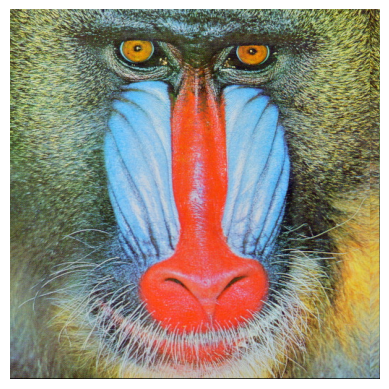

In [ ]:
# Set up and run the Genetic Algorithm
image_path = r"E:\ElecEng vol 7\Artificial Intelegence\THIS\HW\HW2_CA\images\images\baboon.jpg"

ga = GeneticAlgorithm(
    image_path=image_path,
    population_size=100,
    generations=10,
    elite_size=10,
    mutation_rate=0.01,
    selection_method=roulette_selection,      
    crossover_method=Crossover,               
    score_function=lambda ind: ind.fitness    
)

# make it a 6*8 puzzle
ga.rows = 6 #puzzle pieces in rows
ga.columns = 8 #puzzle pieces in columns

best_solution = ga.run()

plt.imshow(best_solution.to_image())
plt.axis("off")
plt.show()



#### the rest of the results on the rest of the pictures are saved in folders. so please check them

an overal conclusion is that by the increase in the 20_128, 15_64, and 15_128 where the best. giving us the idea that higher piece size and generation generally results in better answers , but there is a sweet spot of good answer and low runtime


### Question 1: State Space Size Calculation

* The puzzle grid size is $R \times C = 6 \times 8$.
* The total number of unique puzzle pieces ($N$) is 48.
* The chromosome is a permutation of these 48 unique piece IDs.
* The total number of possible arrangements (the state space size) is the number of possible permutations of $N$ items.

#### State Space Calculation

* Total State Space $= N! = 48! \approx 1.2413 \times 10^{61} \approx 10^{61}$

* The total state space is approximately $10^{61}$ possible arrangements.

### Question 2: Chessboard Puzzle Performance

* The genetic algorithm typically fails to solve the chessboard puzzle.

#### Why the Algorithm Fails

* The **Dissimilarity Function** (based on SSD) cannot tell the difference between the correct fit and many incorrect fits.
* Since the image has a simple, repetitive black-white pattern, nearly any random arrangement where opposite colors touch will have a very low **Dissimilarity score**.
* This results in a **flat fitness landscape**  where almost all solutions look equally "good" to the algorithm.
* The **Selection** process has no strong **fitness gradient** to follow, as all individuals have similar high fitness.
* The population quickly **stagnates** (premature convergence) on an easy, sub-optimal arrangement because there's no genetic pressure to find the one true perfect ordering.\

here are some samples , the highter piece sixe took too long to be executed:

![Genetic Algorithm Fitness Curve](results/chessboard_results/chessboard_10_32.png)
![Genetic Algorithm Fitness Curve](results/chessboard_results/chessboard_10_64.png)
![Genetic Algorithm Fitness Curve](results/chessboard_results/chessboard_10_128.png)
![Genetic Algorithm Fitness Curve](results/chessboard_results/chessboard_15_32.png)

### Question 3: Inadequacy of Simple Crossover for Permutations

* The jigsaw puzzle problem uses a chromosome that is a **permutation** of unique piece IDs.
* The essential constraint for this problem is that every piece ID must appear exactly once in the child chromosome.

* Simple crossover methods, such as one-point or two-point crossover, are designed for binary strings or non-unique integer arrays.
* When these methods are applied to a permutation:
    * They copy segments from one parent and combine them with segments from the second parent.
    * This process frequently results in **illegal chromosomes**.
    * The child will contain **duplicate piece IDs** (genes) and be **missing** other unique piece IDs.

* An illegal chromosome (a chromosome that is not a complete permutation) does not represent a valid puzzle arrangement.
* Using these invalid solutions fundamentally breaks the genetic algorithm's search space and prevents meaningful convergence.
* Therefore, complex, permutation-specific operators (like the Heuristic Crossover) are necessary to maintain the integrity of the chromosome (the complete set of unique piece IDs) while combining the local ordering information from the parents.

### Question 4: Selection Pressure and Genetic Diversity

* The process of **selection** in a Genetic Algorithm involves choosing the fittest individuals to reproduce for the next generation.
* **Selection Pressure** refers to the degree to which fitter individuals are favored over weaker ones during this process.



#### High Selection Pressure and Premature Convergence

* **High Selection Pressure** (like focusing on the very top individuals) strongly favors the very best solutions found early on.
* This pressure quickly pushes the population toward focusing on the current best individuals.
* leading to a rapid loss of Genetic Diversity, that results in the population becoming homogeneous (all individuals look alike).
The algorithm then struggles to escape local optimum because it lacks the necessary variation to explore new regions of the search space , aka, premature convergence, where the algorithm stops improving before finding the true best solution (global optimum).

* NOTE: Genetic Diversity is crucial because it ensures the algorithm retains traits that might be necessary later to solve difficult parts of the puzzle or escape a local optimum.


#### Maintaining Diversity with Tournament Selection

* **Tournament Selection** helps maintain diversity by introducing an element of chance in survival.
* In tournament selection, a small group (the tournament) is randomly chosen, and the best individual within that small group wins a spot as a parent.
* This mechanism allows **weaker individuals** (those not among the top elites of the whole population) to compete within their small, randomly chosen group and still have a chance of survival.
* By allowing slightly weaker solutions to pass their genes to the next generation, **Tournament Selection** slows down the convergence and preserves more genetic material, ultimately leading to better **global exploration** and a higher chance of finding the true optimal solution.

### Question 5: Role of Swap Mutation and Mutation Rate Risks

* **Swap Mutation** is a mutation operator specifically designed for **permutation problems** (like the jigsaw puzzle).
* It works by randomly selecting two positions in the chromosome (the list of piece IDs) and swapping the pieces at those positions.
* This is essential because it maintains the core constraint of the problem: the chromosome remains a complete and valid permutation (no pieces are duplicated or lost).


#### Role of Mutation (General)

* The primary role of mutation is to reintroduce **genetic diversity** into the population.
* It prevents the population from becoming stuck in a local optimum by allowing the search to explore entirely new regions of the search space that might not be reachable through crossover alone.


#### Risks of Mutation Rate

* **Very Low Mutation Rate:**
    * The algorithm runs the risk of **premature convergence** to a local optimum.
    * The lack of diversity means the population quickly becomes homogeneous (similar chromosomes).
    * Once stuck, there are not enough random changes to help the search escape the local optimum and find the global best solution.
    * Exploration is effectively halted, leading to suboptimal results.

* **Very High Mutation Rate:**
    * The algorithm essentially degrades into a **random search** or **random walk** through the search space.
    * The beneficial structures (good local piece pairings) created by the efficient **Crossover** operator are destroyed almost immediately by the high rate of random swapping.
    * The algorithm loses its memory and fails to build upon the improvements of past generations, making the process inefficient.

<div style="color:rgb(235, 66, 32); font-weight: bold;">⚠️ Important Note:</div>  

Using **NumPy arrays** allows you to perform operations on vectors **more efficiently** and **faster**.

**Avoid using `for` loops** whenever possible, as vectorized operations in NumPy are **optimized for performance** and significantly reduce execution time.